# 2026-01-22 read data

In [ ]:
import os
import pandas as pd
import yaml
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

cm = 1/2.54
fontsize = 10


def df_to_plot_dict(df, metric_keys, mode_mapping):
    """
    df: df_mean
    metric_keys: metric list
    mode_mapping: mode
    """
    plot_dict = {}

    for mode, df_mode in df.groupby("mode"):
        mode_name = mode_mapping.get(mode, mode)
        plot_dict[mode_name] = {}

        for _, row in df_mode.iterrows():
            model = row["Model"]

            plot_dict[mode_name][model] = {
                k: float(row[k]) for k in metric_keys
            }

    return plot_dict


def plot_heatmap(data, metrics, use_annot=True, sort_by='Validity', save_path=None):
    """
    Plots a heatmap where rows are models and columns are metrics,
    sorted by a specific metric (e.g., internal_energy).
    """

    factor_labels = {
        'Validity': 'Validity',
        'QED': 'QED',
        'SA': 'SA',
        'Uniqueness': 'Uniqueness',
        'Diversity': 'Diversity',
        
        'Atom Type': 'Atom Type',
        'Ring Type': 'Ring Type',
        'Functional Group': 'Functional Group',
    }
    
    df_denovo = pd.DataFrame(index=[factor_labels[m] for m in metrics])
    for model_name, model_data in data['De novo'].items():
        df_denovo[model_name] = [model_data.get(m, np.nan) for m in metrics]

    df_denovo = df_denovo.loc[:, df_denovo.loc[sort_by].sort_values(ascending=False).index]

    df_hit2lead = pd.DataFrame(index=[factor_labels[m] for m in metrics])
    for model_name, model_data in data['Hit to Lead'].items():
        df_hit2lead[model_name] = [model_data.get(m, np.nan) for m in metrics]
    
    df_hit2lead = df_hit2lead.loc[:, df_hit2lead.loc[sort_by].sort_values(ascending=False).index]
    
    df_final = pd.concat([df_denovo, df_hit2lead], axis=1)

    
    plt.figure(figsize=(9,4.5), dpi=300)
    sns.set(font_scale=1.0)

    colors = [
        (0.0, '#a50026'),   
        (0.25, '#f46d43'),  
        (0.5,  '#f7f7f7'),  
        (0.75, '#74add1'),  
        (1.0,  '#313695')   
    ]


    cmap = LinearSegmentedColormap.from_list("symmetric_coolwarm", colors)
    
    ax = sns.heatmap(
        df_final,
        annot=use_annot,
        fmt=".3f",
        # cmap="Greens",
        cmap=cmap,
        vmin=0,
        vmax=1.0,
        linewidths=0.5,
        linecolor="gray",
        annot_kws={"fontsize":fontsize-4}   #7
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=fontsize-3)

    cbar.set_label("Score",fontdict={'size': fontsize-2})  #8
    ax.tick_params(
        axis='both',        
        which='both',       
        direction='inout', 
        length=4,           
        width=0.8,          
        colors='black',     
        bottom=False, top=True, left=True, right=False  
    )

    ax.xaxis.tick_top()                  
    ax.xaxis.set_label_position('top')   
    plt.xticks(rotation=45, ha='left',rotation_mode='anchor',fontsize=fontsize-4)  #7.5
    plt.yticks(fontsize=fontsize-4)  #8
    
    y_line = 1.22    
    y_text = 1.25    
    
    group_map = {
        'De novo': list(data['De novo'].keys()),
        'Hit to Lead': list(data['Hit to Lead'].keys())
    }
    for label, model_names in group_map.items():
        idxs = [list(df_final.columns).index(name) for name in model_names]
        print(idxs)
        
        if label == 'De novo':
            x_start = 0.5
            x_end = 9.5
        elif label == 'Hit to Lead':
            x_start = 10.5
            x_end = 16.5
        
        x_center = (x_start + x_end) / 2

        ax.plot([x_start-0.2, x_end+0.2], [y_line, y_line],
                color='black', lw=0.6, clip_on=False, transform=ax.get_xaxis_transform())

        ax.text(x_center, y_text, label,
                ha='center', va='bottom', fontsize=8,
                clip_on=False, transform=ax.get_xaxis_transform())
    
    
    
    # plt.title("Model Performance Across Metrics", fontsize=14)
    plt.tight_layout()
    # save svg
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path,format="svg",bbox_inches='tight')
    # print(f"Heatmap saved to {save_file}")
    plt.show()
    

data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["De_novo_Results", "Hit_to_Lead_Results"]


TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    'TamGen_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    "TamGen_generated_molecules": "TamGen",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "DiffSBDD-C",
    "diffSBDD_cond_moad_generated_molecules": "DiffSBDD-M",
}

TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    "PGMG_Hit_to_Lead",
    "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "DiffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "DiffSBDD-M",
    "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "ShEPhERD",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
    "PGMG_Hit_to_Lead": "PGMG",
}

results_all = []
results_seen = []
results_unseen = []

for round_name in round_list:
    for mode in mode_list:
        if mode == "De_novo_Results":
            task_list = TASK_LIST_DENOVO
            name_mapping = DENOVO_NAME_MAPPING
        else:
            task_list = TASK_LIST_H2L
            name_mapping = H2L_NAME_MAPPING
        
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)

                results_all.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "mode": mode,
                    "Validity": result['metrics']['Validity']['all']['Validity'],
                    "QED": result['metrics']['QED']['all']['QED'],
                    "SA": result['metrics']['SA']['all']['SA'],
                    "Uniqueness": result['metrics']['Uniqueness']['all']['Uniqueness'],
                    "Diversity": result['metrics']['Diversity']['all']['Diversity'],
                    "Atom Type": result['metrics']['MotifDist']['all']['Atom Type_Score'],
                    "Ring Type": result['metrics']['MotifDist']['all']['Ring Type_Score'],
                    "Functional Group": result['metrics']['MotifDist']['all']['Functional Group_Score'],
                })
                
                results_seen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "mode": mode,
                    "Validity": result['metrics']['Validity']['seen']['Validity'],
                    "QED": result['metrics']['QED']['seen']['QED'],
                    "SA": result['metrics']['SA']['seen']['SA'],
                    "Uniqueness": result['metrics']['Uniqueness']['seen']['Uniqueness'],
                    "Diversity": result['metrics']['Diversity']['seen']['Diversity'],
                    "Atom Type": result['metrics']['MotifDist']['seen']['Atom Type_Score'],
                    "Ring Type": result['metrics']['MotifDist']['seen']['Ring Type_Score'],
                    "Functional Group": result['metrics']['MotifDist']['seen']['Functional Group_Score'],
                })
                
                results_unseen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "mode": mode,
                    "Validity": result['metrics']['Validity']['unseen']['Validity'],
                    "QED": result['metrics']['QED']['unseen']['QED'],
                    "SA": result['metrics']['SA']['unseen']['SA'],
                    "Uniqueness": result['metrics']['Uniqueness']['unseen']['Uniqueness'],
                    "Diversity": result['metrics']['Diversity']['unseen']['Diversity'],
                    "Atom Type": result['metrics']['MotifDist']['unseen']['Atom Type_Score'],
                    "Ring Type": result['metrics']['MotifDist']['unseen']['Ring Type_Score'],
                    "Functional Group": result['metrics']['MotifDist']['unseen']['Functional Group_Score'],
                })
df_results_all = pd.DataFrame(results_all)
df_results_seen = pd.DataFrame(results_seen)
df_results_unseen = pd.DataFrame(results_unseen)

metric_cols = [
    "Validity", "QED", "SA", "Uniqueness", "Diversity",
    "Atom Type", "Ring Type", "Functional Group"
]

df_mean_all = (
    df_results_all
    .groupby(["Model", "mode"], as_index=False)[metric_cols]
    .mean()
    .round(3)
)

df_mean_seen = (
    df_results_seen
    .groupby(["Model", "mode"], as_index=False)[metric_cols]
    .mean()
    .round(3)
)

df_mean_unseen = (
    df_results_unseen
    .groupby(["Model", "mode"], as_index=False)[metric_cols]
    .mean()
    .round(3)
)


MODE_NAME_MAPPING = {
    "De_novo_Results": "De novo",
    "Hit_to_Lead_Results": "Hit to Lead",
}

top_8_keys = [
    'Validity',
    'QED',
    'SA',
    'Uniqueness',
    'Diversity',
    'Atom Type',
    'Ring Type',
    'Functional Group',
]

data_all = df_to_plot_dict(
    df_mean_all,
    metric_keys=top_8_keys,
    mode_mapping=MODE_NAME_MAPPING,
)

data_seen = df_to_plot_dict(
    df_mean_seen,
    metric_keys=top_8_keys,
    mode_mapping=MODE_NAME_MAPPING,
)

data_unseen = df_to_plot_dict(
    df_mean_unseen,
    metric_keys=top_8_keys,
    mode_mapping=MODE_NAME_MAPPING,
)

[7, 4, 5, 9, 2, 3, 0, 8, 1, 6]
[14, 15, 4, 5, 11, 16, 10]


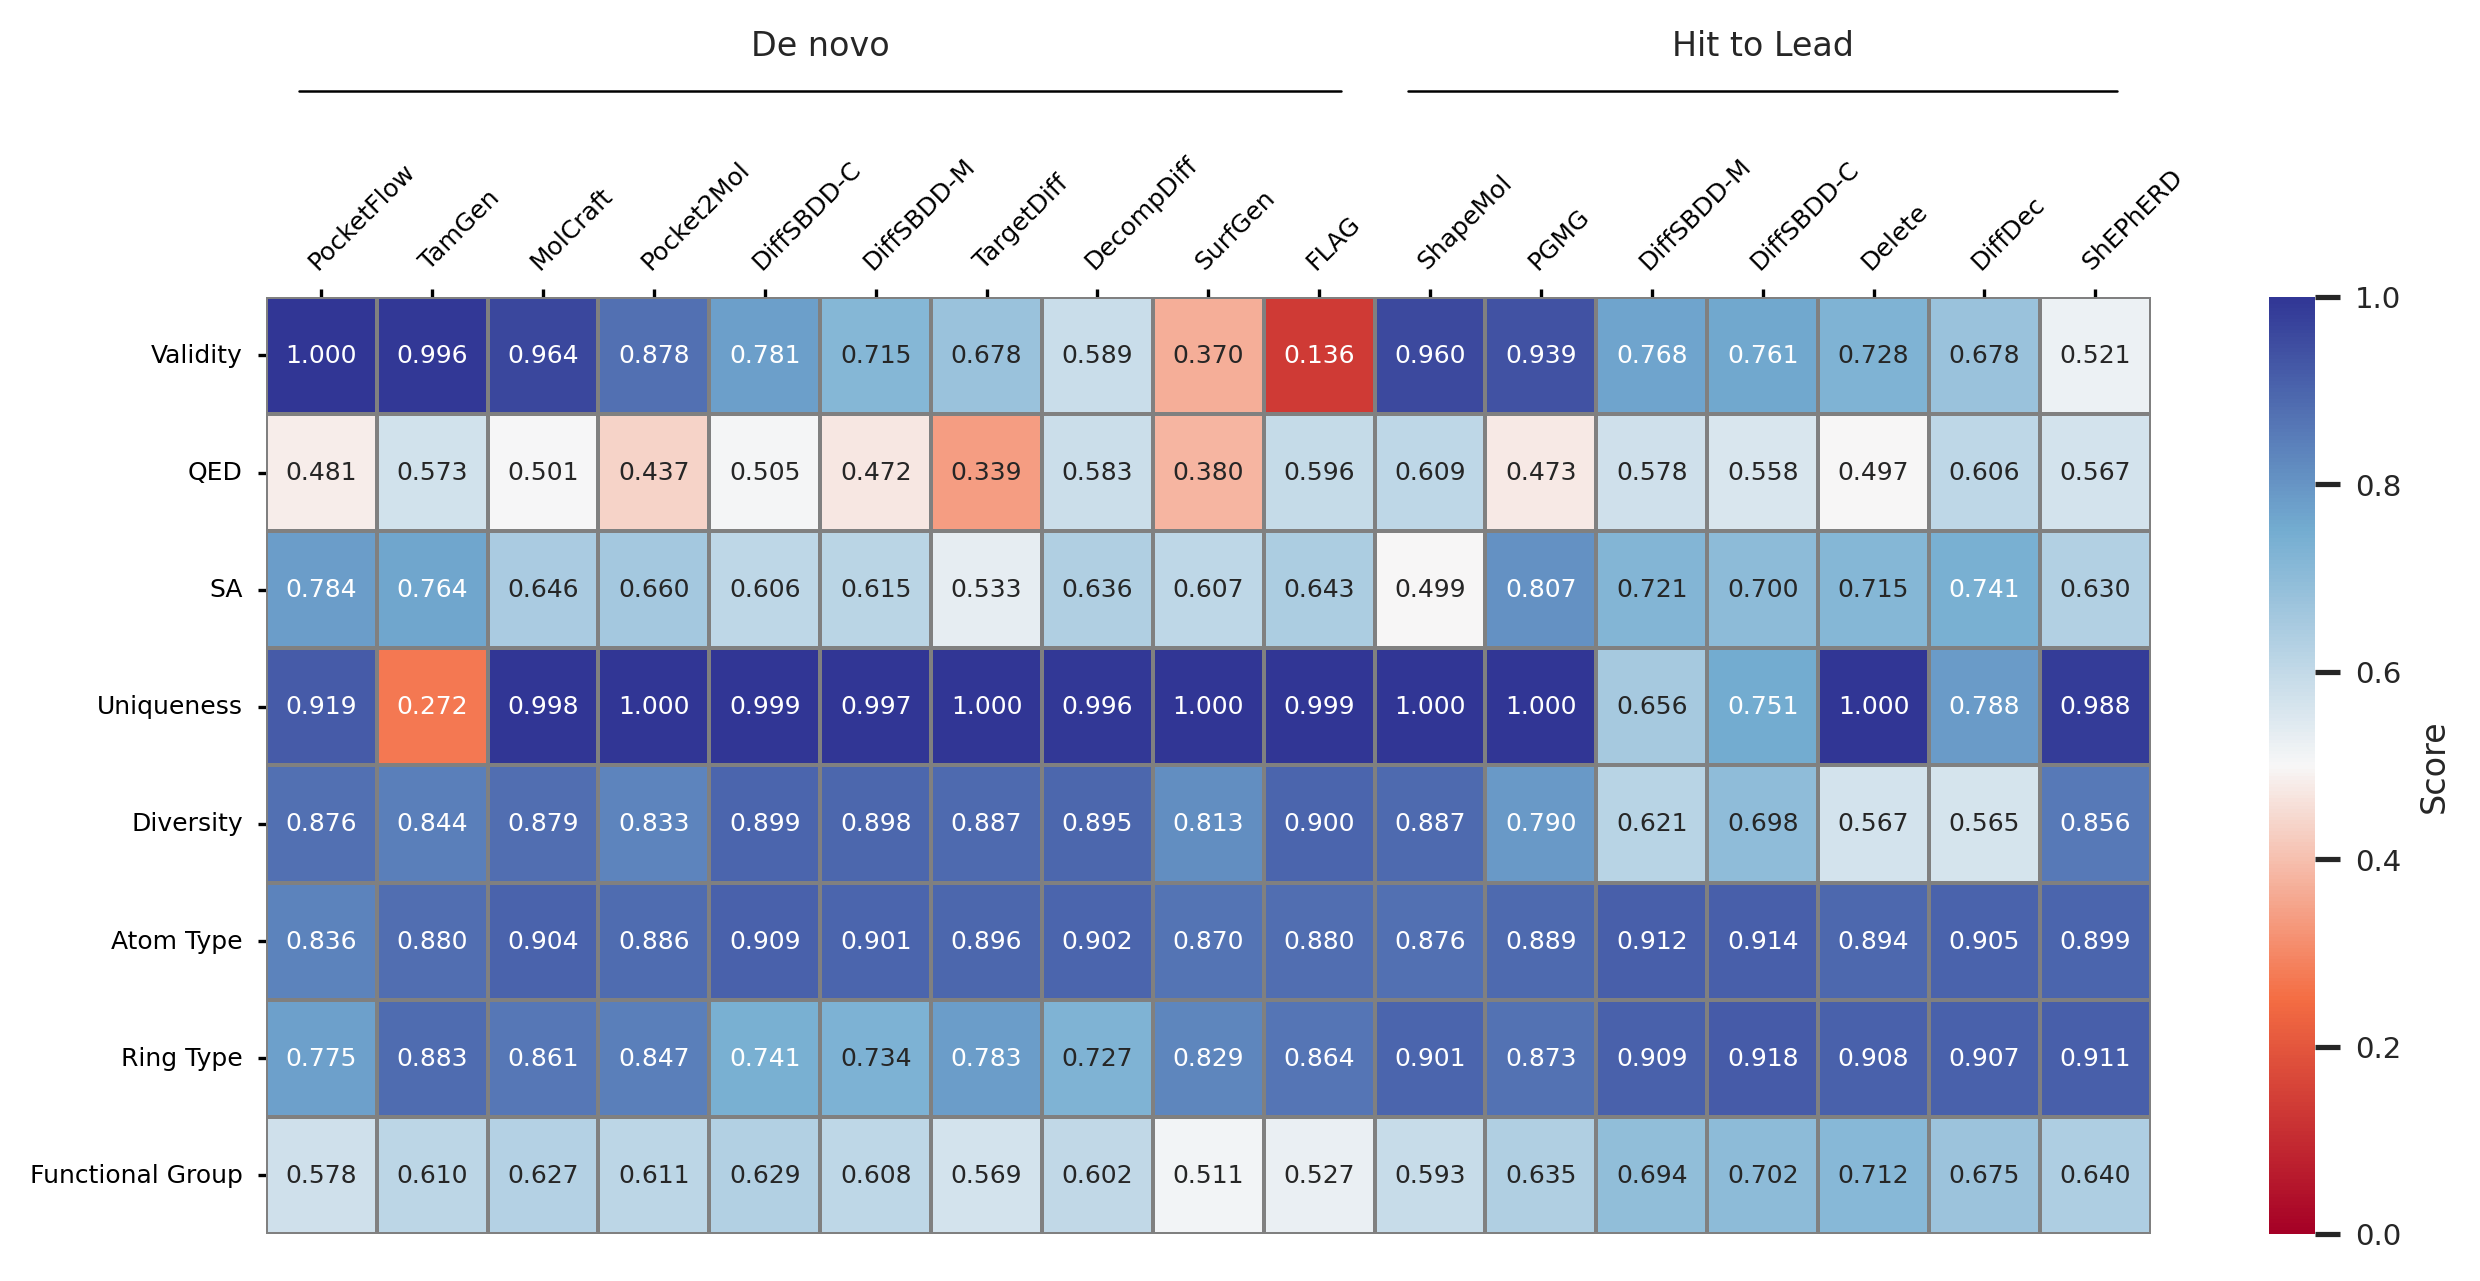

[7, 4, 5, 9, 2, 3, 0, 8, 1, 6]
[14, 15, 4, 5, 11, 16, 10]


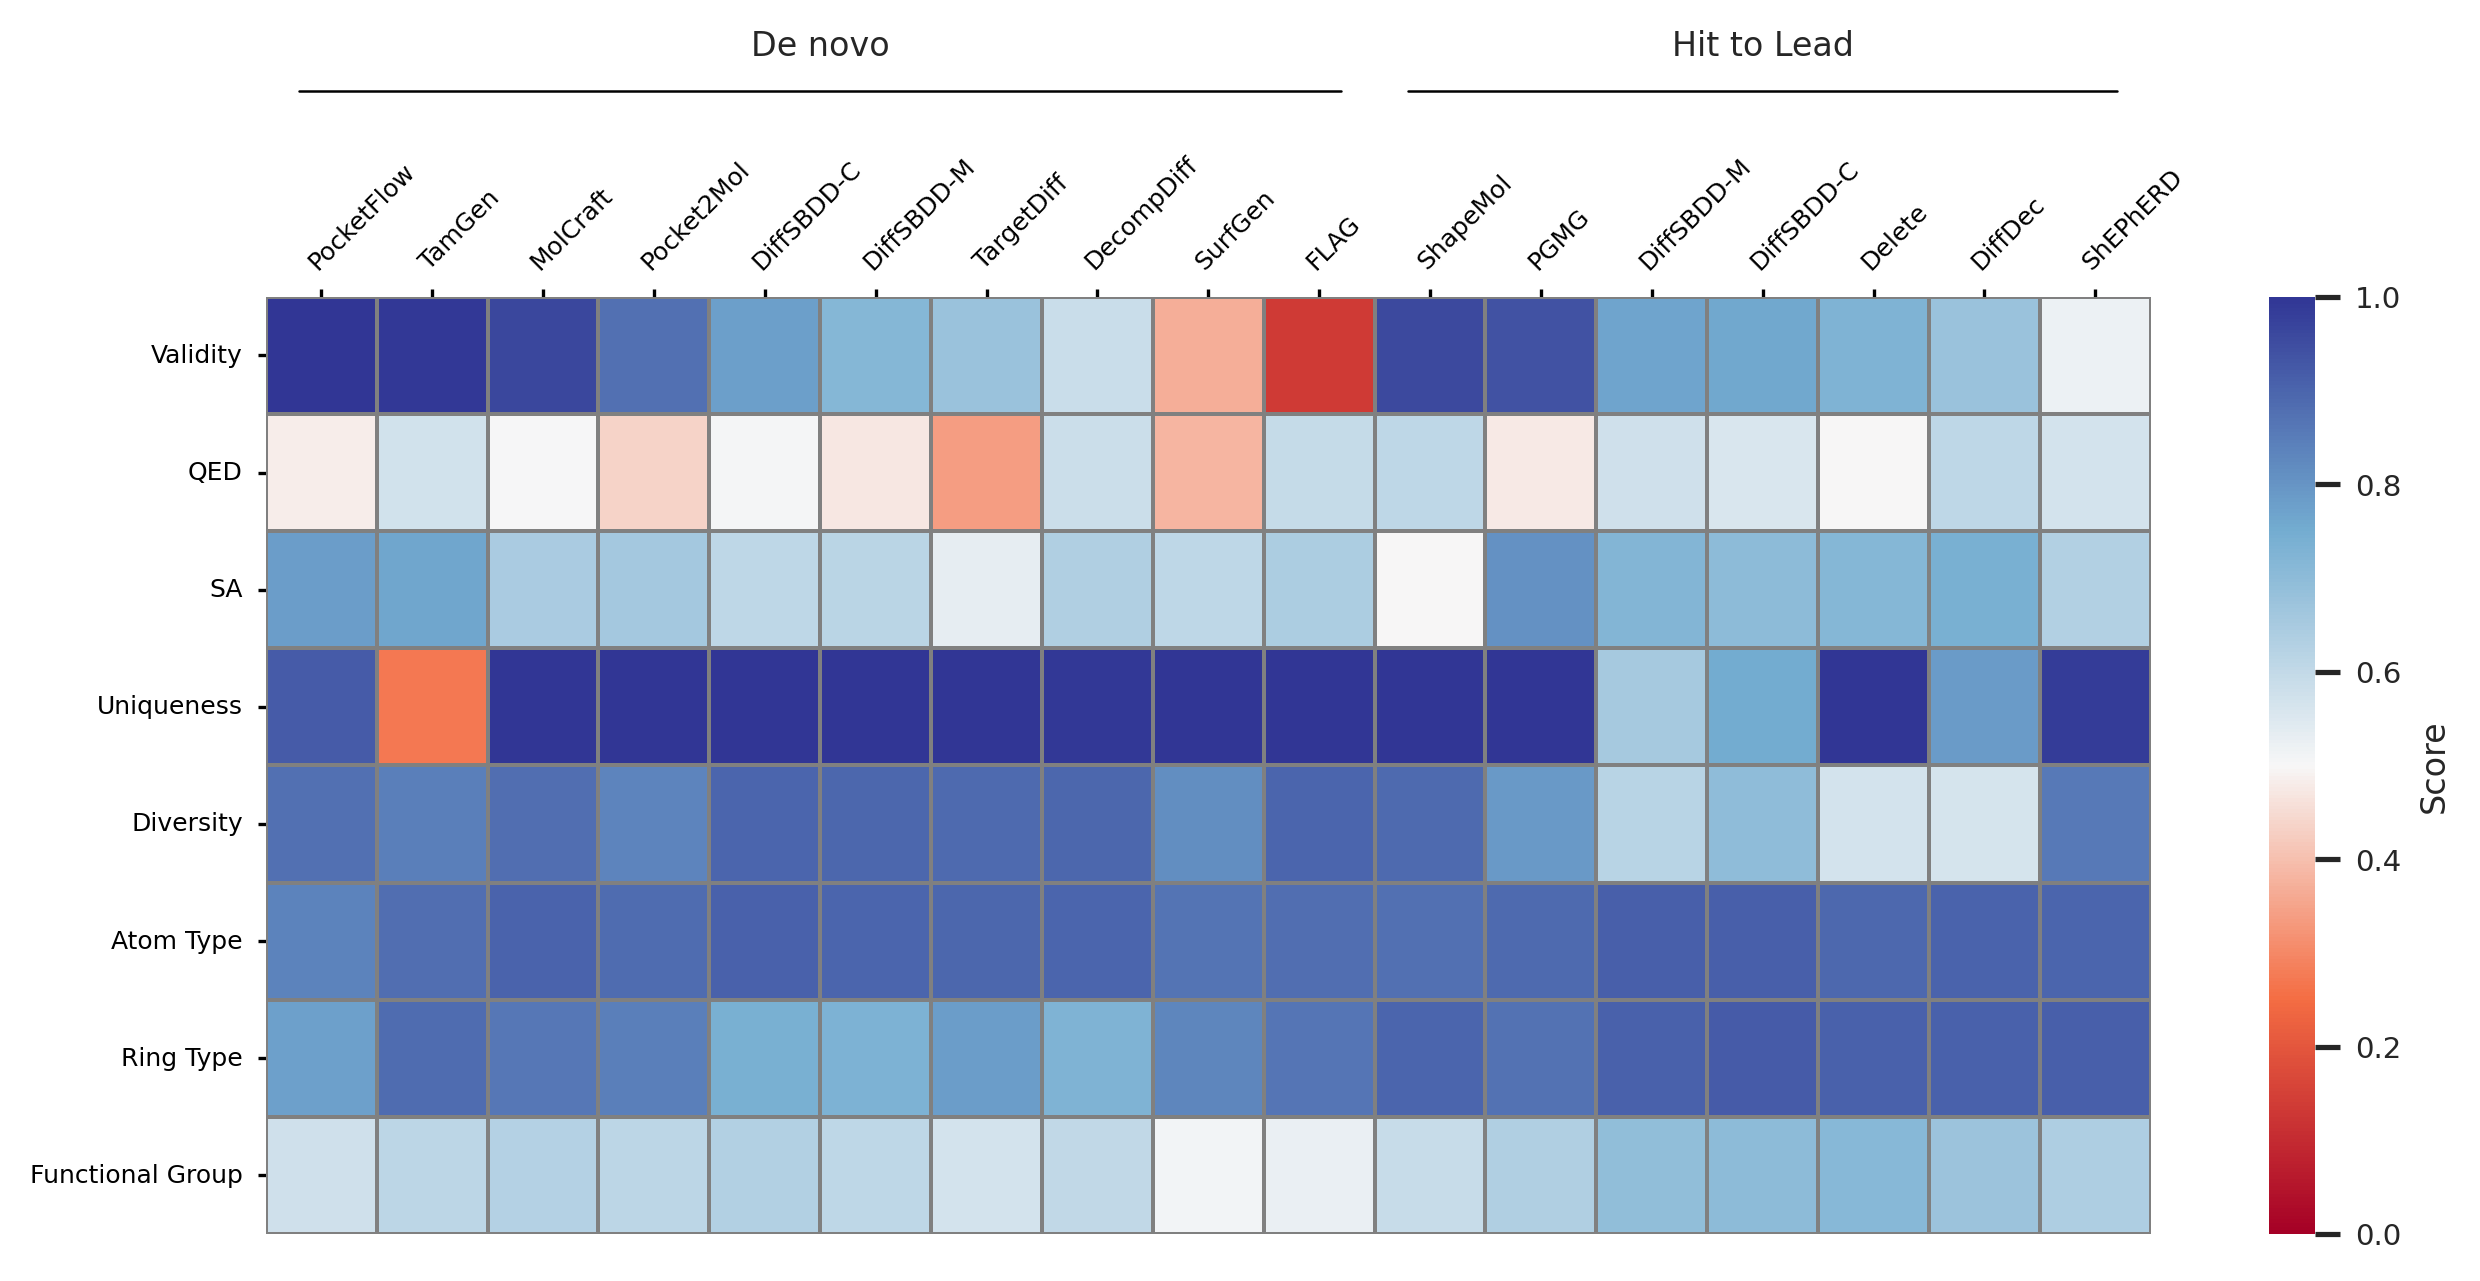

[7, 4, 5, 9, 2, 3, 0, 8, 1, 6]
[14, 15, 4, 5, 11, 16, 10]


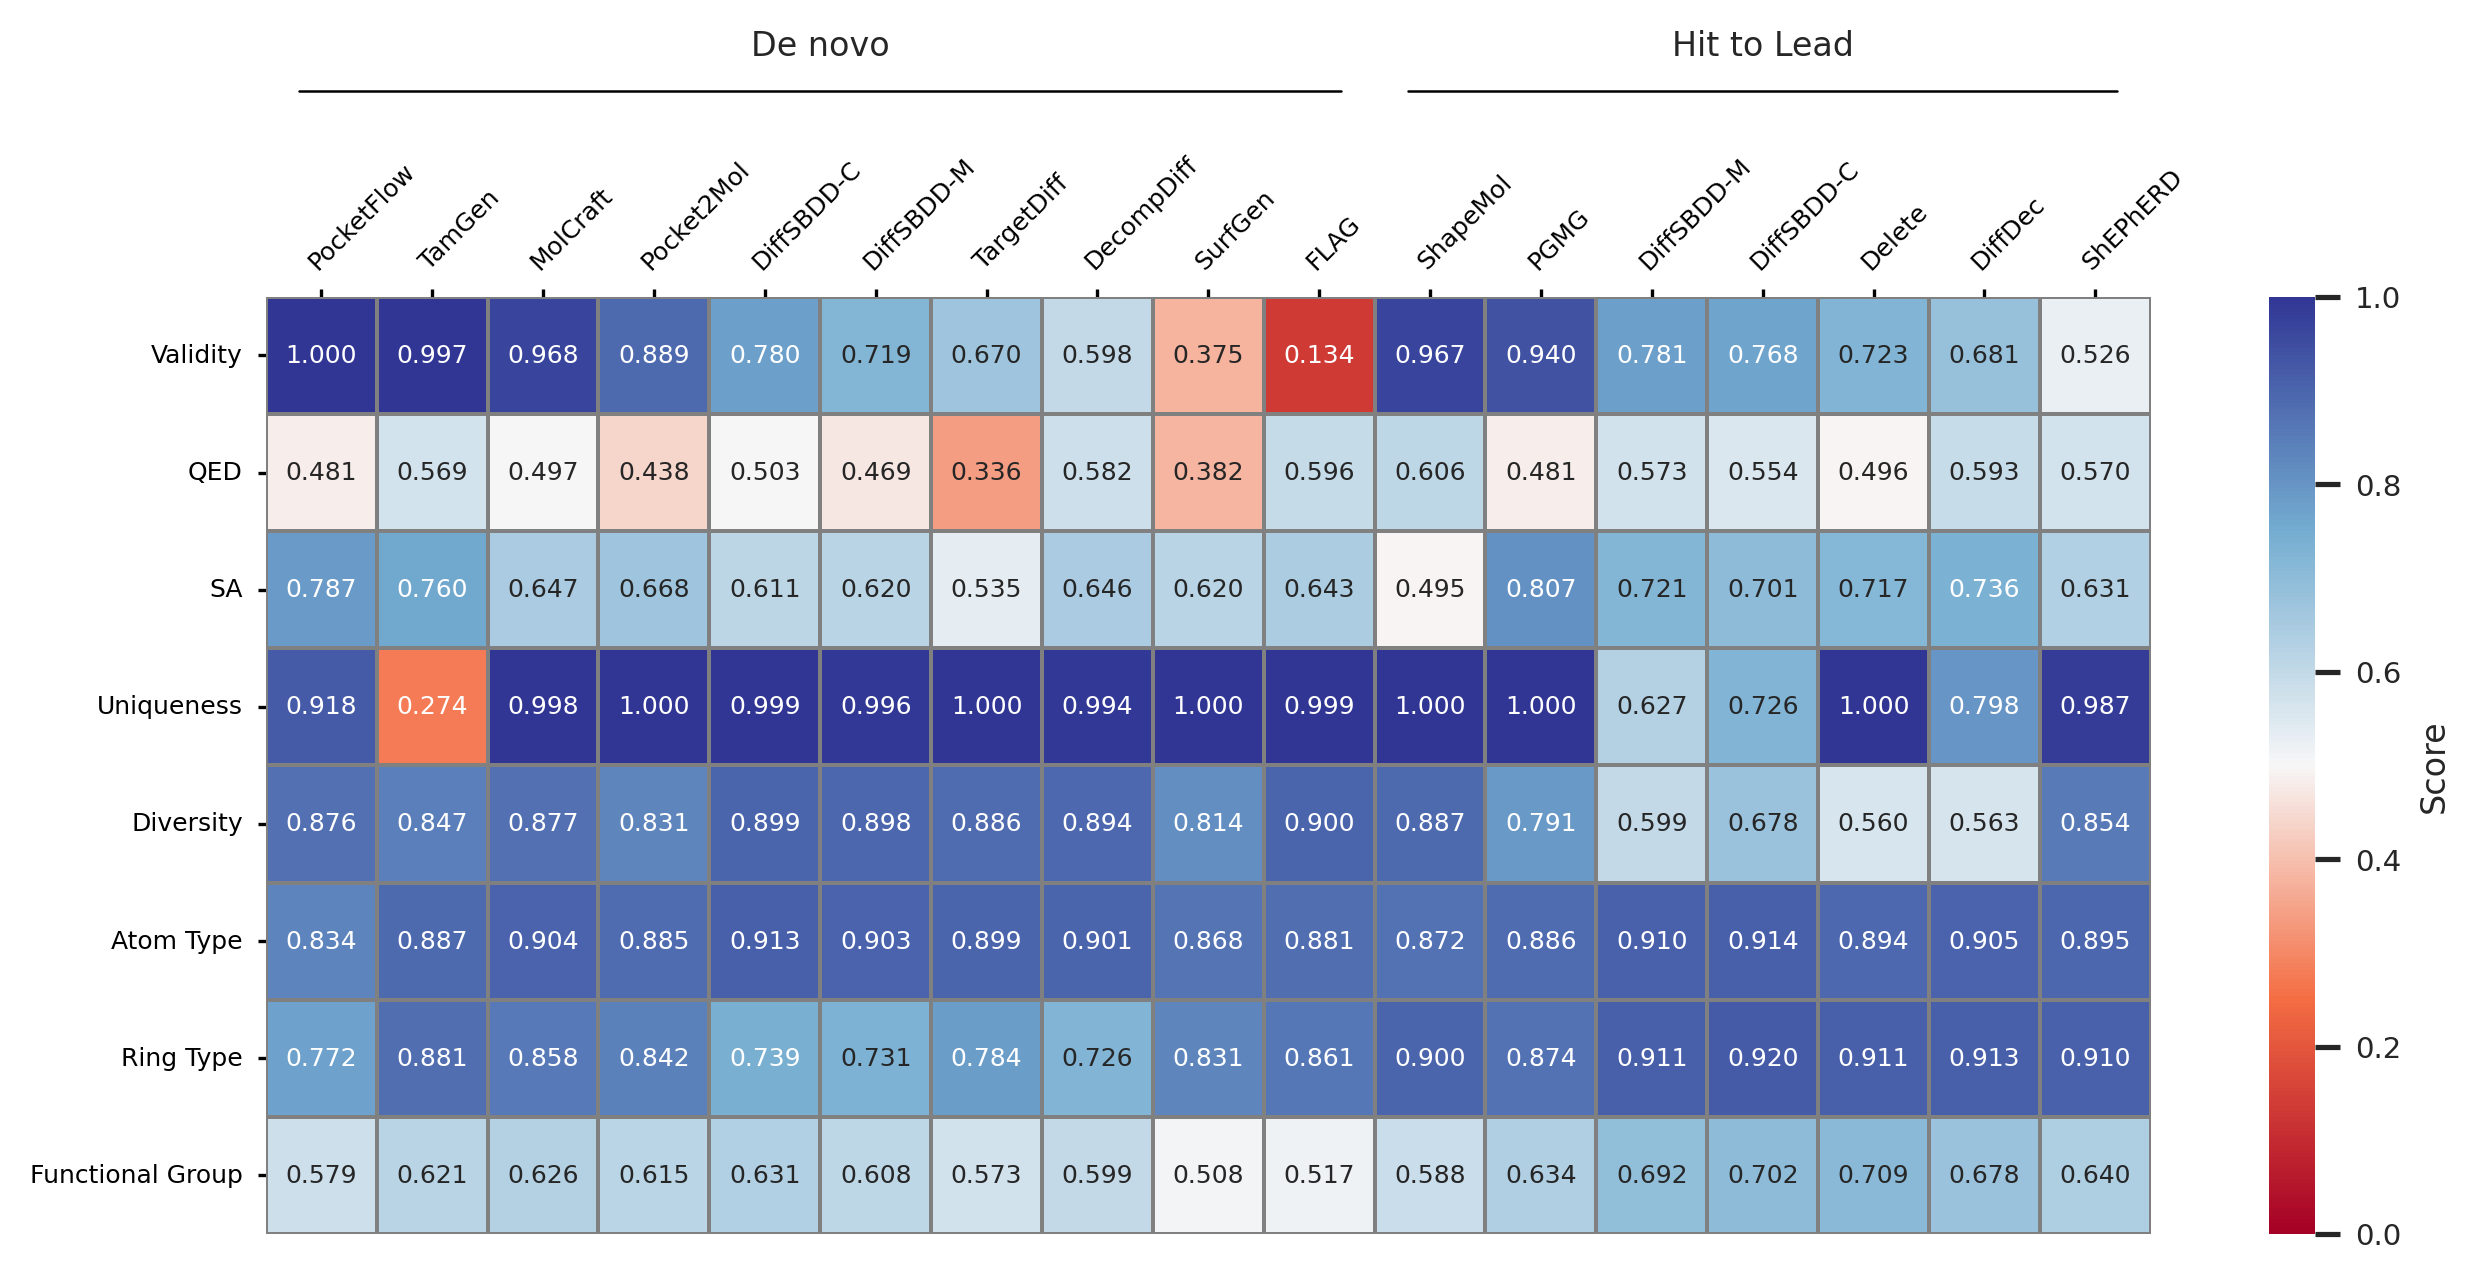

[7, 4, 5, 9, 2, 3, 0, 8, 1, 6]
[14, 15, 4, 5, 11, 16, 10]


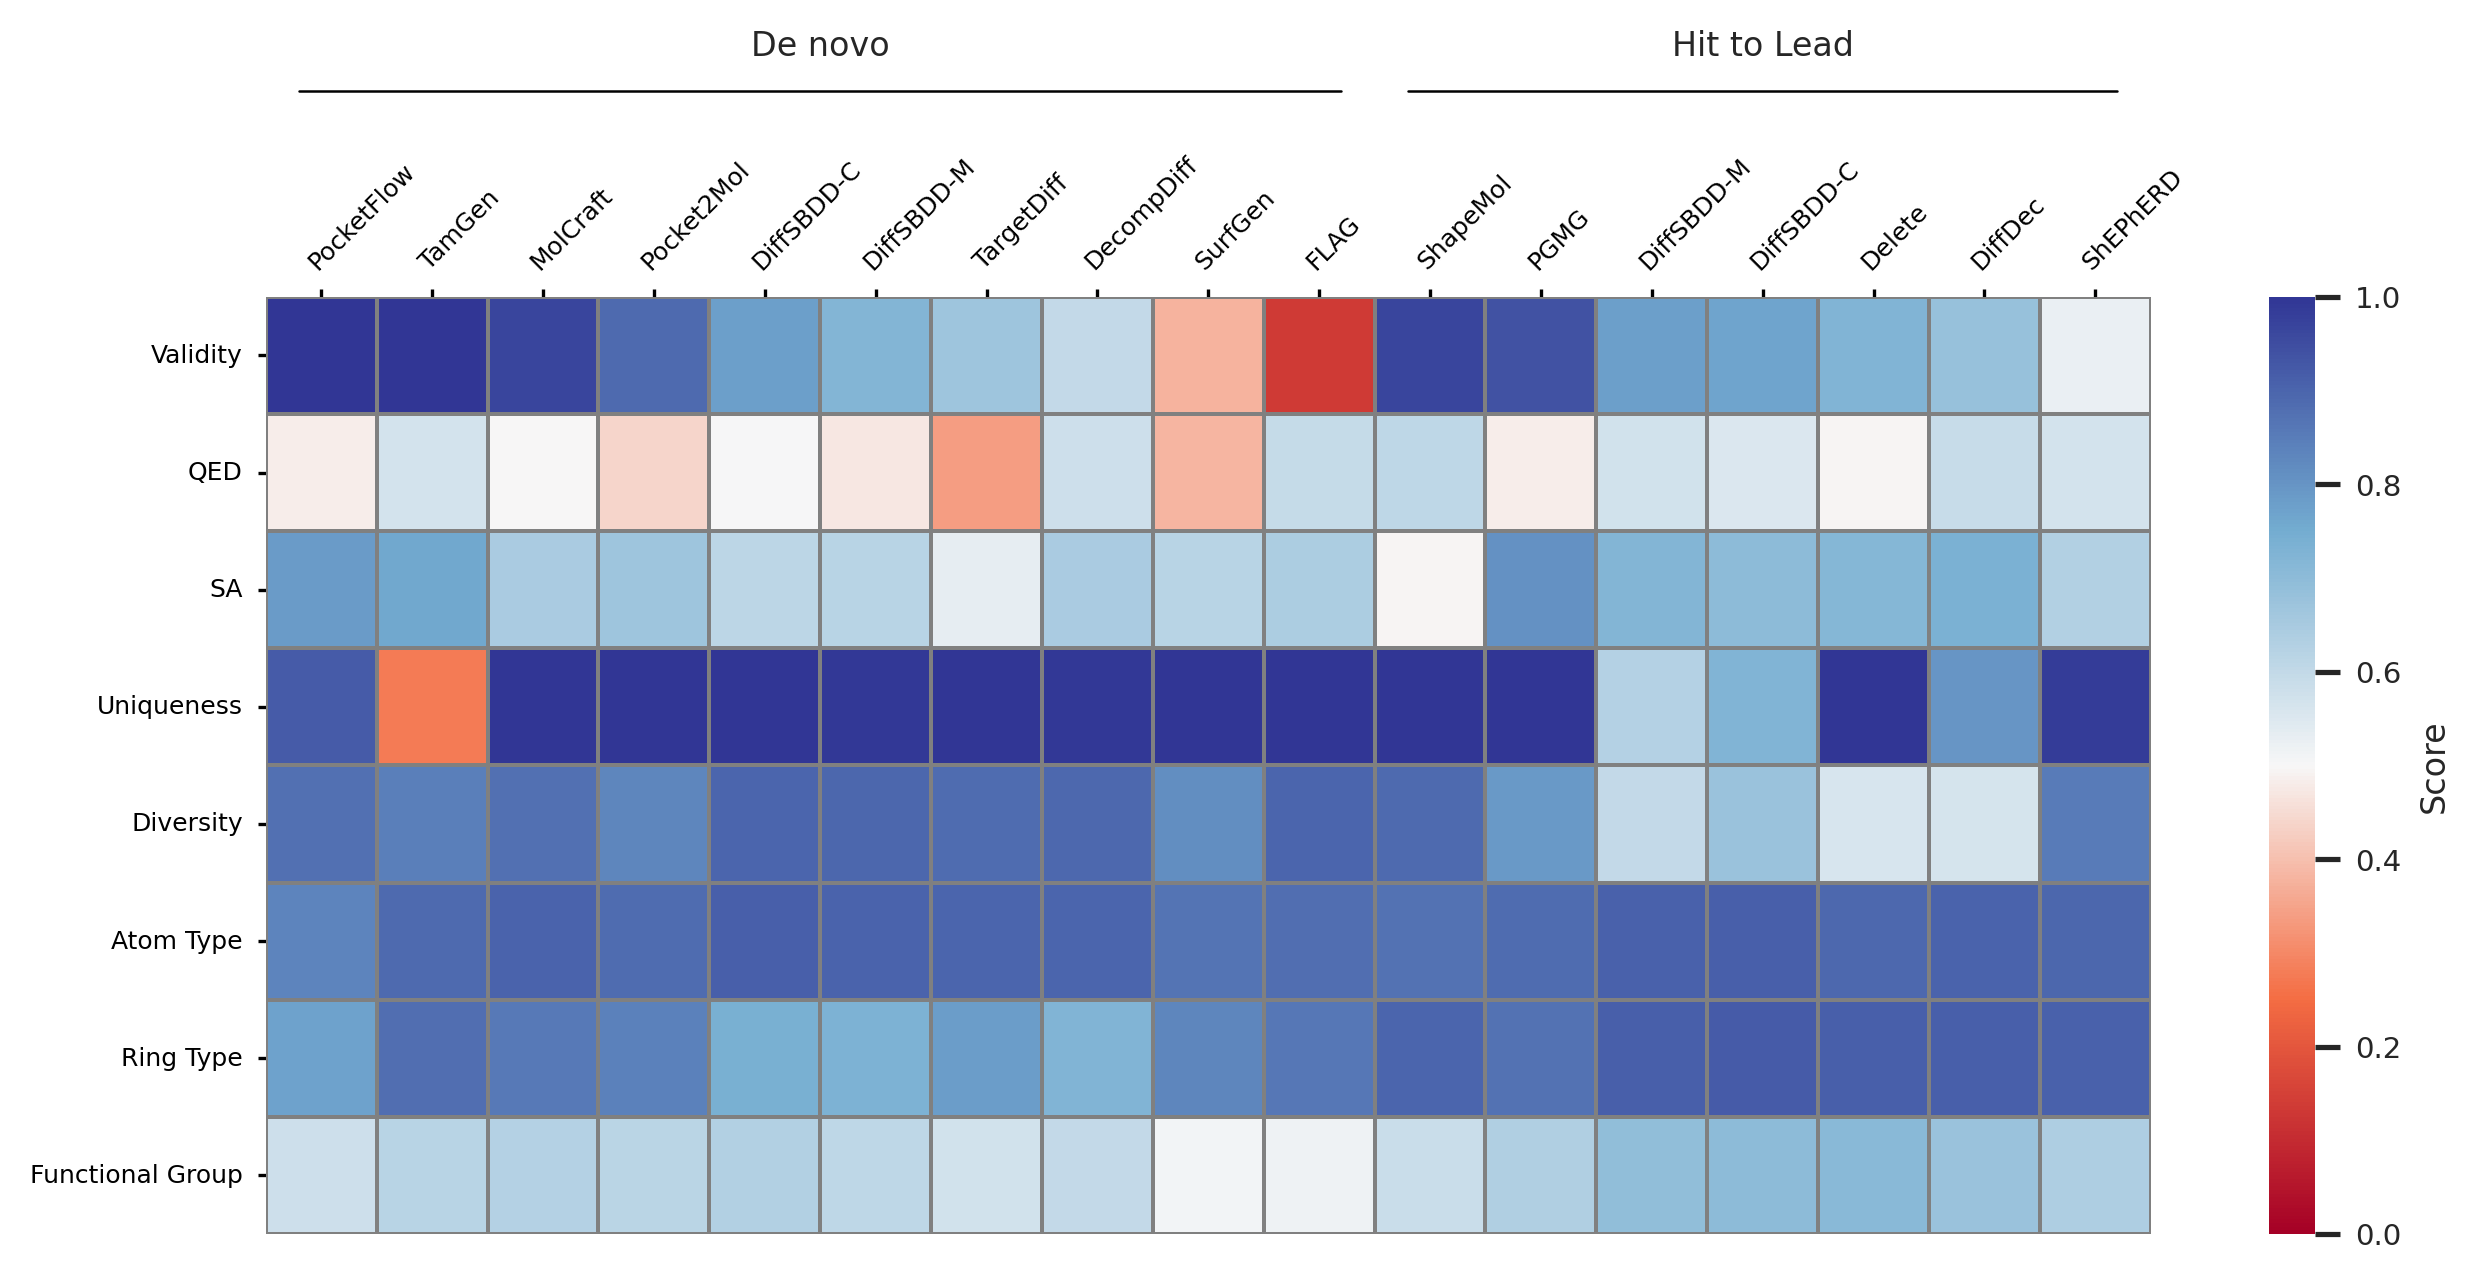

[7, 4, 5, 9, 2, 3, 0, 8, 1, 6]
[13, 15, 4, 5, 11, 16, 10]


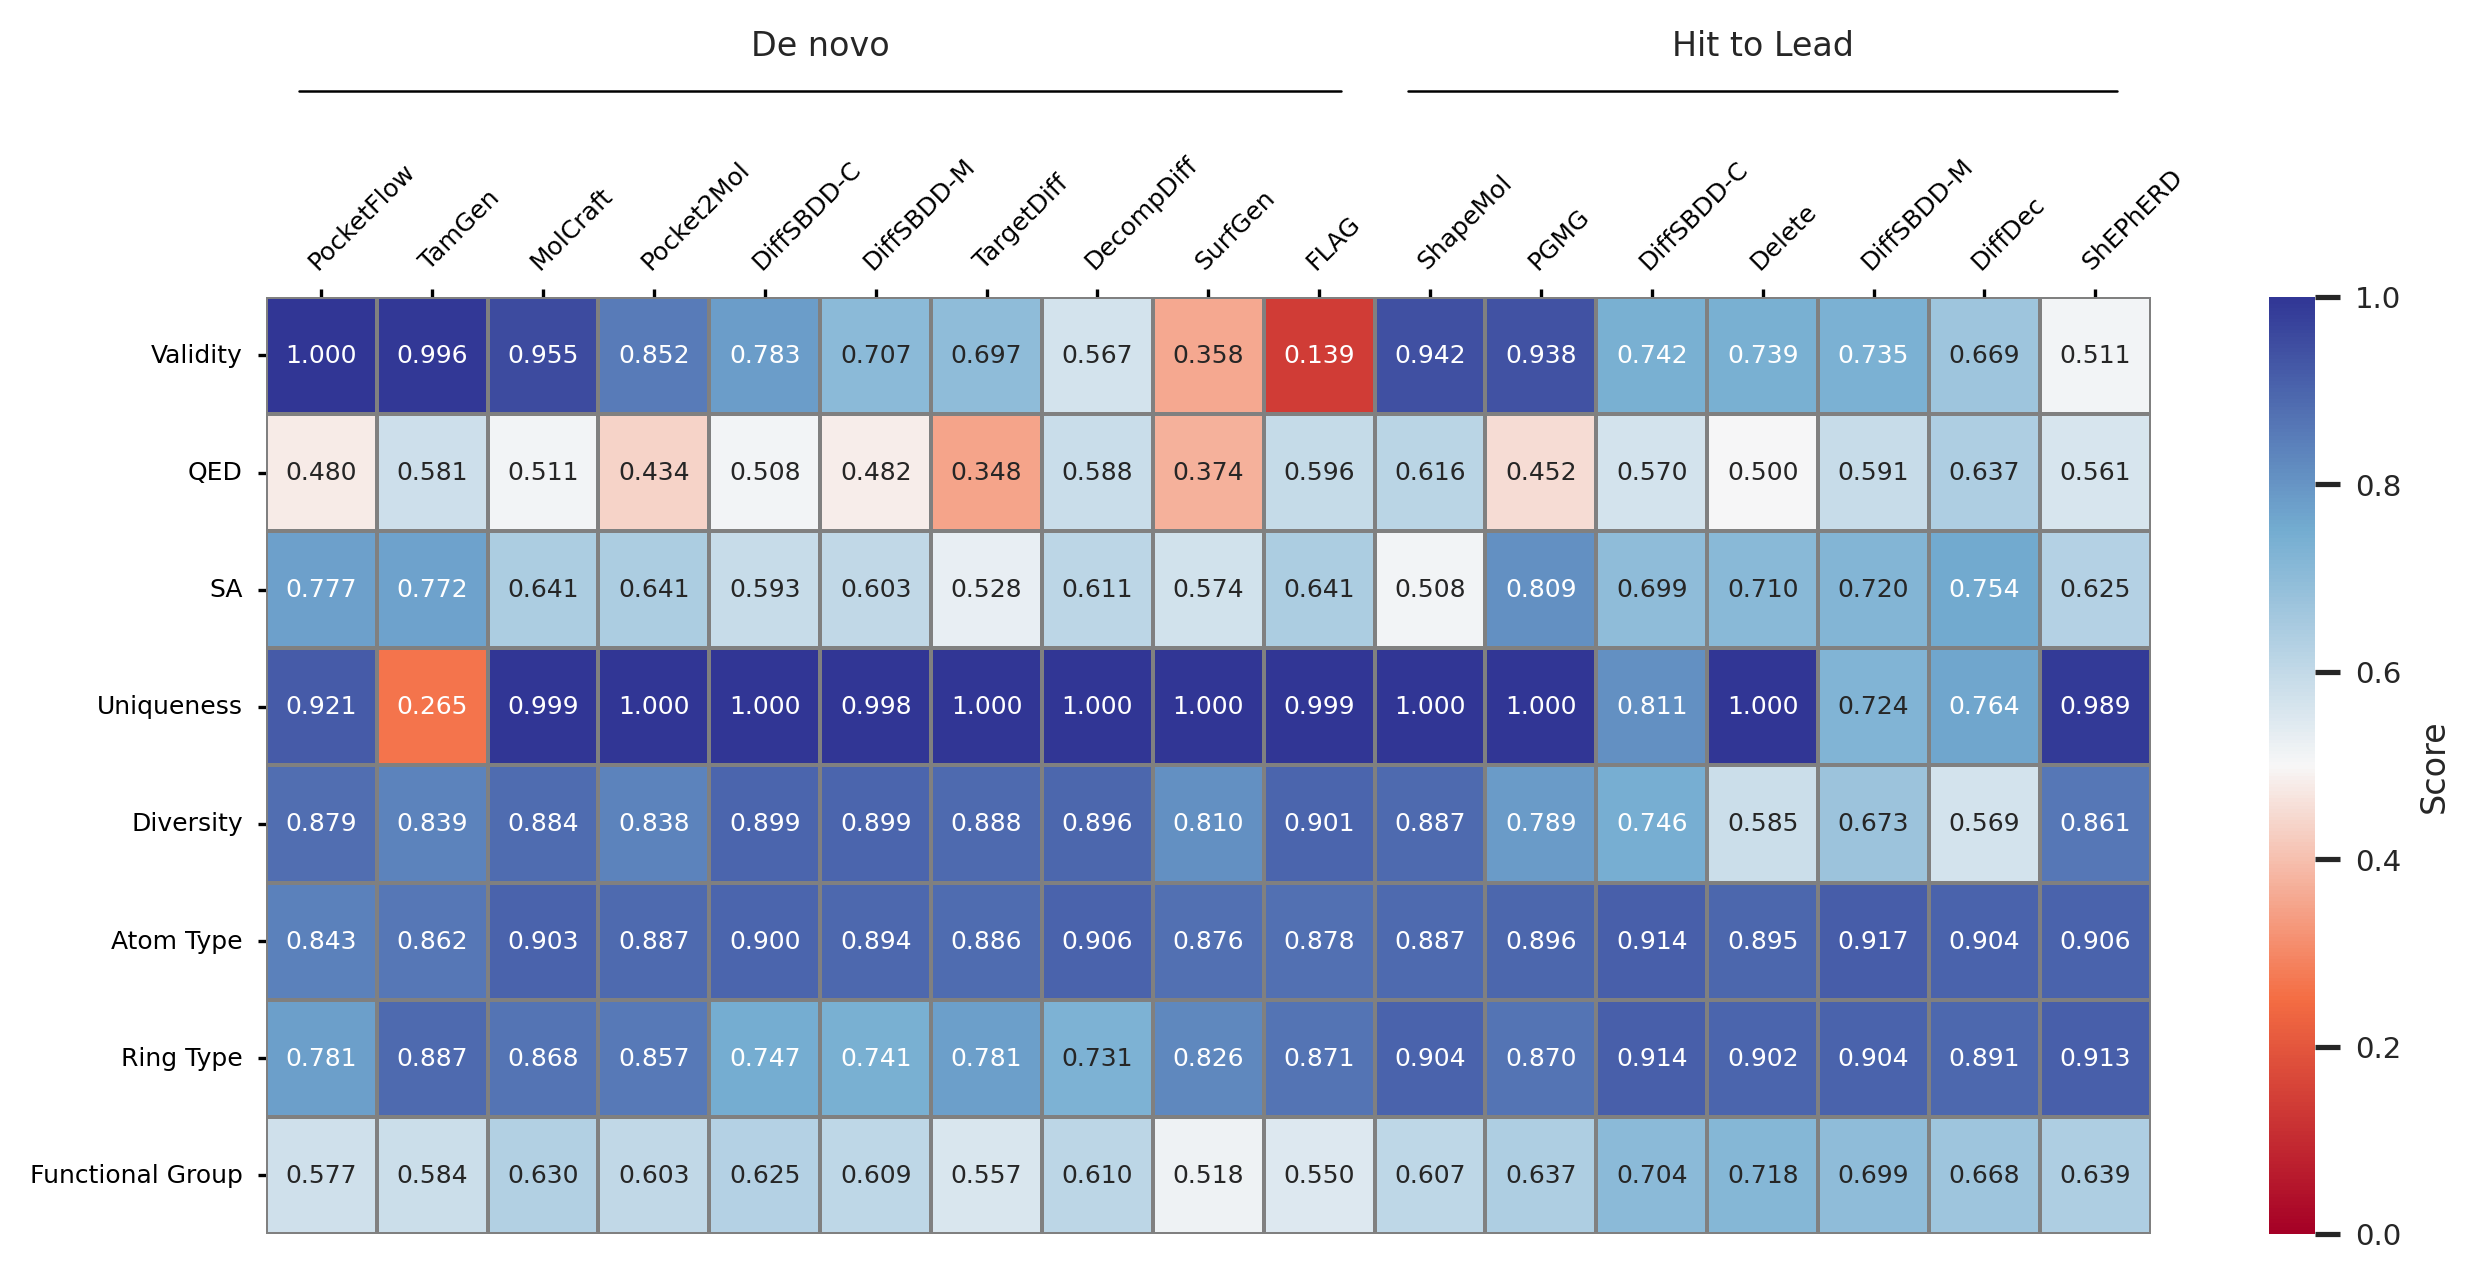

[7, 4, 5, 9, 2, 3, 0, 8, 1, 6]
[13, 15, 4, 5, 11, 16, 10]


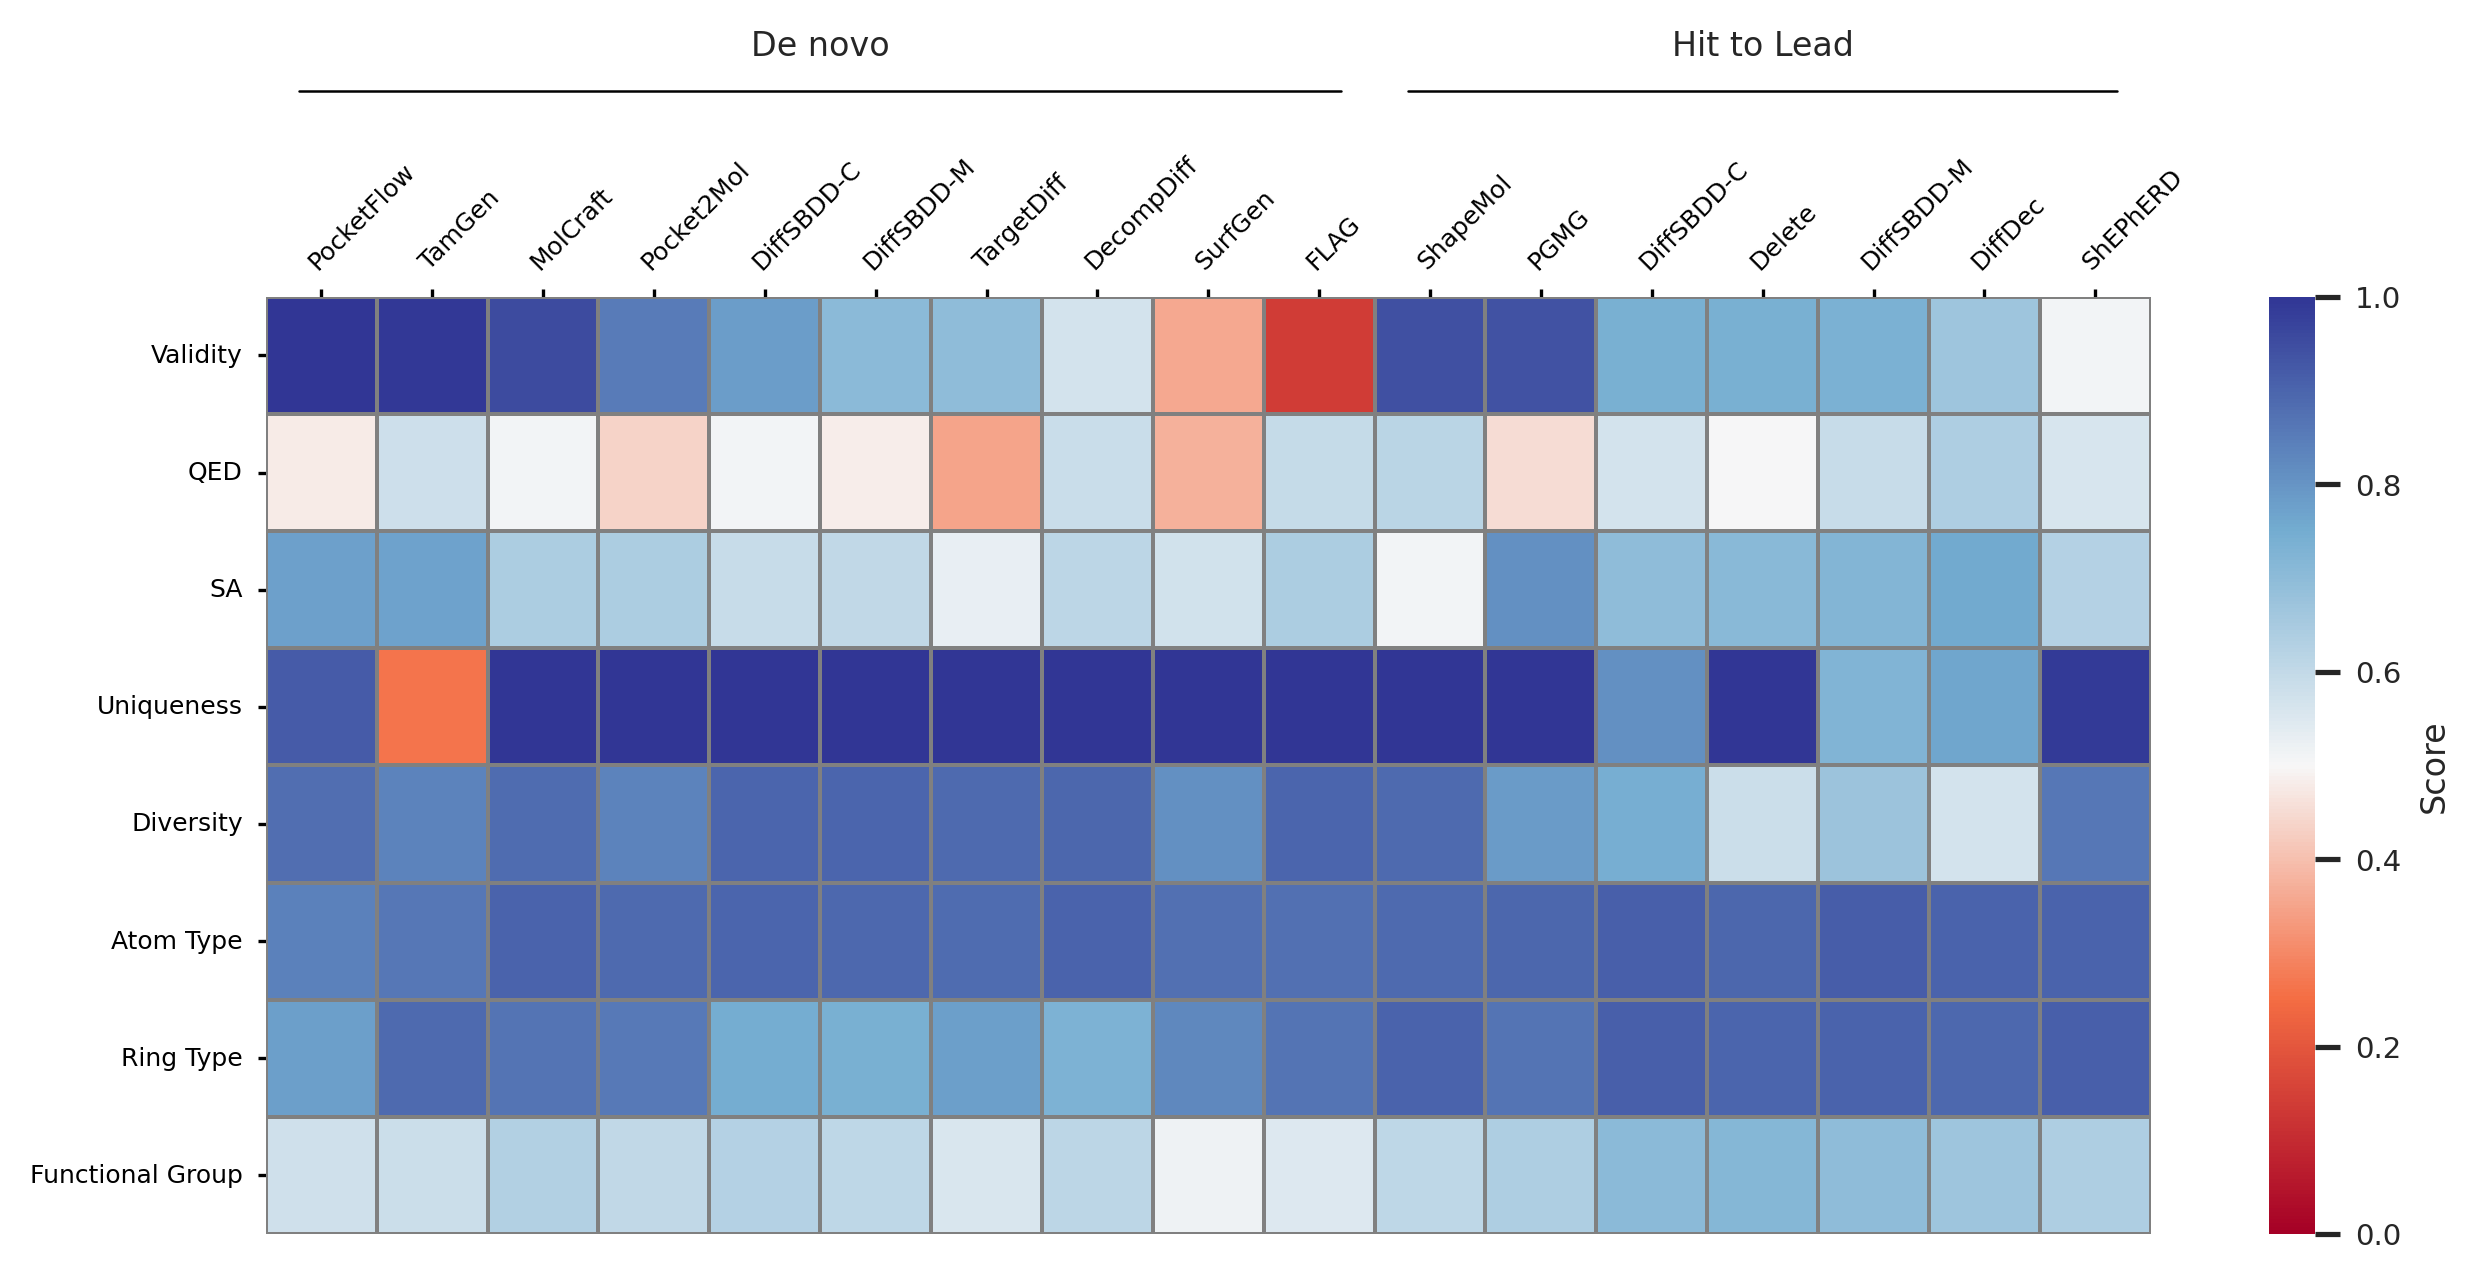

In [31]:
plot_heatmap(data_all, top_8_keys, save_path="../final_plot/output/00-2D_General_Properties_heatmap_all.svg")
plot_heatmap(data_all, top_8_keys, use_annot=False, save_path="../final_plot/output/00-2D_General_Properties_heatmap_all_NoNumber.svg")

plot_heatmap(data_seen, top_8_keys, save_path="../final_plot/output/00-2D_General_Properties_heatmap_seen.svg")
plot_heatmap(data_seen, top_8_keys, use_annot=False, save_path="../final_plot/output/00-2D_General_Properties_heatmap_seen_NoNumber.svg")

plot_heatmap(data_unseen, top_8_keys, save_path="../final_plot/output/00-2D_General_Properties_heatmap_unseen.svg")
plot_heatmap(data_unseen, top_8_keys, use_annot=False, save_path="../final_plot/output/00-2D_General_Properties_heatmap_unseen_NoNumber.svg")